# 03 - Inférence MCMC pour le Modèle Heston

Ce notebook présente l'inférence MCMC pour estimer les paramètres du modèle Heston.

## Objectifs

1. Configurer l'échantillonneur NUTS
2. Lancer l'inférence sur les données synthétiques
3. Analyser les résultats : paramètres estimés vs vrais paramètres
4. Vérifier la convergence (R-hat, ESS, trace plots)

## 1. Importation des Bibliothèques

In [1]:
import sys
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
import numpyro
import numpyro.distributions as dist
import time

# Configuration du style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Import des modules
sys.path.append('../src')
from models.heston_model import HestonModel, HestonModelConditional
from simulation.heston_sim import HestonSimulator
from inference.mcmc_sampler import MCMCSampler, MCMCSamplerConfig
from inference.diagnostics import MCMCDiagnostics

# Configuration de NumPyro
numpyro.set_platform('cpu')
numpyro.set_host_device_count(4)  # 4 chaînes en parallèle

## 2. Génération de Données Synthétiques

In [2]:
# Paramètres du modèle Heston (vrais paramètres)
true_params = {
    'S0': 100.0,
    'v0': 0.04,
    'mu': 0.05,
    'kappa': 2.0,
    'theta': 0.04,
    'sigma': 0.3,
    'rho': -0.7,
    'T': 1.0,
    'dt': 1/252,
    'seed': 42
}

print("Vrais paramètres du modèle Heston:")
for key, value in true_params.items():
    print(f"  {key}: {value}")

Vrais paramètres du modèle Heston:
  S0: 100.0
  v0: 0.04
  mu: 0.05
  kappa: 2.0
  theta: 0.04
  sigma: 0.3
  rho: -0.7
  T: 1.0
  dt: 0.003968253968253968
  seed: 42


In [3]:
# Simulation des données
simulator = HestonSimulator(**true_params)
S, v, t = simulator.simulate(n_paths=1)

# Calcul des rendements
returns = simulator.get_returns()

print("\nDonnées synthétiques générées:")
print(f"  Nombre d'observations: {len(returns)}")
print(f"  Prix initial: {S[0, 0]:.4f}")
print(f"  Prix final: {S[-1, 0]:.4f}")
print(f"  Rendement total: {(S[-1, 0] / S[0, 0] - 1) * 100:.2f}%")


Données synthétiques générées:
  Nombre d'observations: 252
  Prix initial: 100.0000
  Prix final: 106.1298
  Rendement total: 6.13%


## 3. Définition du Modèle Probabiliste

In [4]:
# Création du modèle Heston (approche par défaut basée sur les moments)
heston_model = HestonModel(
    S0=true_params['S0'],
    dt=true_params['dt'],
    mu=None,  # μ sera estimé
    use_moments_likelihood=True  # Vraisemblance basée sur les moments
)

print("Modèle Heston créé!")
print(f"  S0: {heston_model.S0}")
print(f"  dt: {heston_model.dt}")
print(f"  mu: {heston_model.mu}")
print(f"  use_moments_likelihood: {heston_model.use_moments_likelihood}")

Modèle Heston créé!
  S0: 100.0
  dt: 0.003968253968253968
  mu: None
  use_moments_likelihood: True


## 4. Configuration de l'Échantillonneur NUTS

In [5]:
# Configuration de l'échantillonneur MCMC
mcmc_config = MCMCSamplerConfig.get_default_config()

print("Configuration MCMC:")
for key, value in mcmc_config.items():
    print(f"  {key}: {value}")

Configuration MCMC:
  num_warmup: 1000
  num_samples: 2000
  num_chains: 4
  chain_method: parallel
  progress_bar: True
  jit_model_args: False
  target_accept_prob: 0.8
  max_tree_depth: 10
  init_strategy: uniform


In [6]:
# Création de l'échantillonneur
sampler = MCMCSampler(
    model=heston_model.model,
    **mcmc_config
)

print("Échantillonneur NUTS configuré!")

Échantillonneur NUTS configuré!


## 5. Lancement de l'Inférence MCMC

In [7]:
# Préparation des données
returns_jax = jnp.array(returns.T)  # Shape: (1, n_obs)

# Clé aléatoire pour JAX
rng_key = jax.random.PRNGKey(42)

# Exécution de l'inférence
start_time = time.time()
samples = sampler.run(rng_key, returns_jax)
end_time = time.time()

print(f"\nInférence terminée en {end_time - start_time:.2f} secondes!")

Configuration MCMC:
  Warm-up: 1000
  Samples: 2000
  Chains: 4
  Chain method: parallel
  Target accept prob: 0.8
  Max tree depth: 10
  Init strategy: uniform

Démarrage de l'inférence MCMC...


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

Inférence terminée en 3.67 secondes

=== DEBUG: Structure des échantillons ===
log_kappa: shape = (4, 2000), ndim = 2
log_sigma: shape = (4, 2000), ndim = 2
log_theta: shape = (4, 2000), ndim = 2
log_v0: shape = (4, 2000), ndim = 2
mu: shape = (4, 2000), ndim = 2
rho: shape = (4, 2000), ndim = 2
=== FIN DEBUG ===


Inférence terminée en 3.67 secondes!


## 6. Analyse des Résultats

In [8]:
# Affichage du résumé de l'inférence
sampler.print_summary()

RÉSUMÉ DE L'INFÉRENCE MCMC

Configuration:
  Warm-up: 1000
  Samples: 2000
  Chains: 4
  Temps d'inférence: 3.67 secondes

Statistiques Postérieures:
--------------------------------------------------------------------------------

log_kappa:
  Moyenne: 0.694182
  Écart-type: 0.296680
  Médiane: 0.690174
  IC 95%: [0.112007, 1.268082]

log_sigma:
  Moyenne: -1.210201
  Écart-type: 0.293885
  Médiane: -1.207883
  IC 95%: [-1.774927, -0.632831]

log_theta:
  Moyenne: -3.217177
  Écart-type: 0.238419
  Médiane: -3.227596
  IC 95%: [-3.664697, -2.728035]

log_v0:
  Moyenne: -3.218635
  Écart-type: 0.299762
  Médiane: -3.214185
  IC 95%: [-3.810457, -2.639642]

mu:
  Moyenne: 0.056316
  Écart-type: 0.089130
  Médiane: 0.056377
  IC 95%: [-0.119362, 0.230508]

rho:
  Moyenne: -0.668537
  Écart-type: 0.178463
  Médiane: -0.678455
  IC 95%: [-0.963208, -0.292459]



## 7. Comparaison avec les Vrais Paramètres

In [9]:
# Comparaison avec les vrais paramètres
sampler.print_comparison(true_params)

COMPARAISON AVEC LES VRAIS PARAMÈTRES

mu:
  Vrai: 0.050000
  Estimé: 0.056316
  Erreur: 0.006316
  Erreur relative: 12.63%
  Dans IC 95%: ✓

rho:
  Vrai: -0.700000
  Estimé: -0.668537
  Erreur: 0.031463
  Erreur relative: 4.49%
  Dans IC 95%: ✓



## 8. Diagnostics de Convergence

In [10]:
# Création des diagnostics
diagnostics = MCMCDiagnostics(samples)

# Affichage des diagnostics
diagnostics.print_diagnostics()

DIAGNOSTICS DE CONVERGENCE MCMC

log_kappa:
  R-hat: 1.1592 ✗ (Convergence insuffisante)
  ESS: 2601 ✓ (Excellent)

log_sigma:
  R-hat: 1.1842 ✗ (Convergence insuffisante)
  ESS: 1663 ✓ (Excellent)

log_theta:
  R-hat: 1.2342 ✗ (Convergence insuffisante)
  ESS: 1924 ✓ (Excellent)

log_v0:
  R-hat: 1.1199 ✗ (Convergence insuffisante)
  ESS: 2098 ✓ (Excellent)

mu:
  R-hat: 1.0366 ✓ (Convergence acceptable)
  ESS: 2341 ✓ (Excellent)

rho:
  R-hat: 1.1688 ✗ (Convergence insuffisante)
  ESS: 1327 ✓ (Excellent)



## 9. Visualisation des Résultats

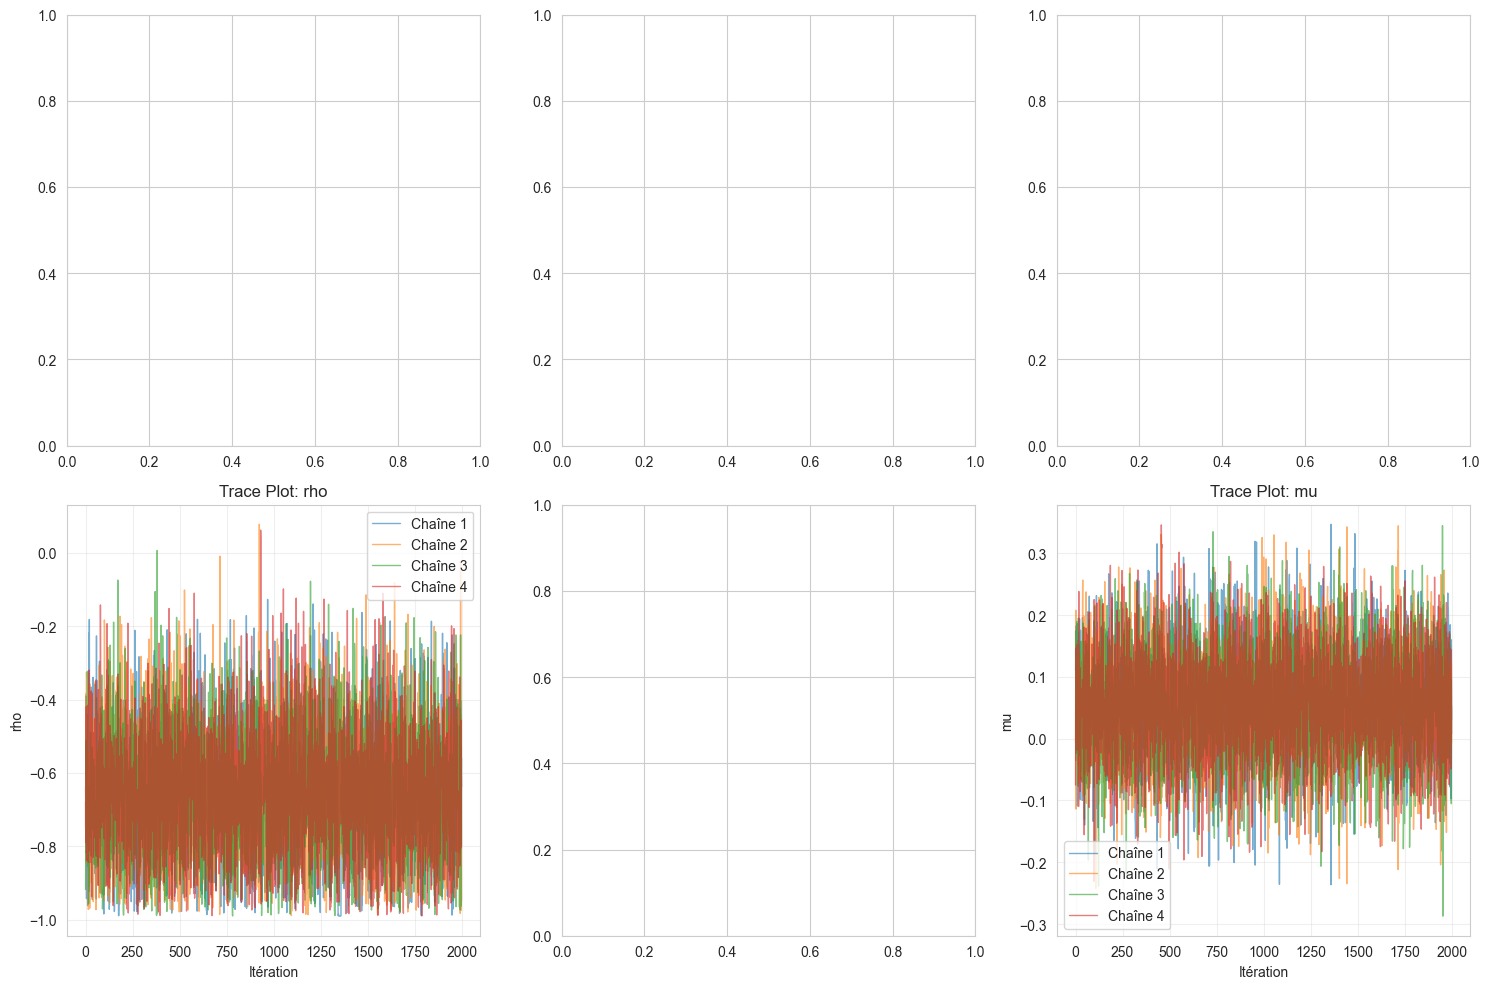

In [11]:
# Trace plots
diagnostics.plot_trace(param_names=['kappa', 'theta', 'sigma', 'rho', 'v0', 'mu'])

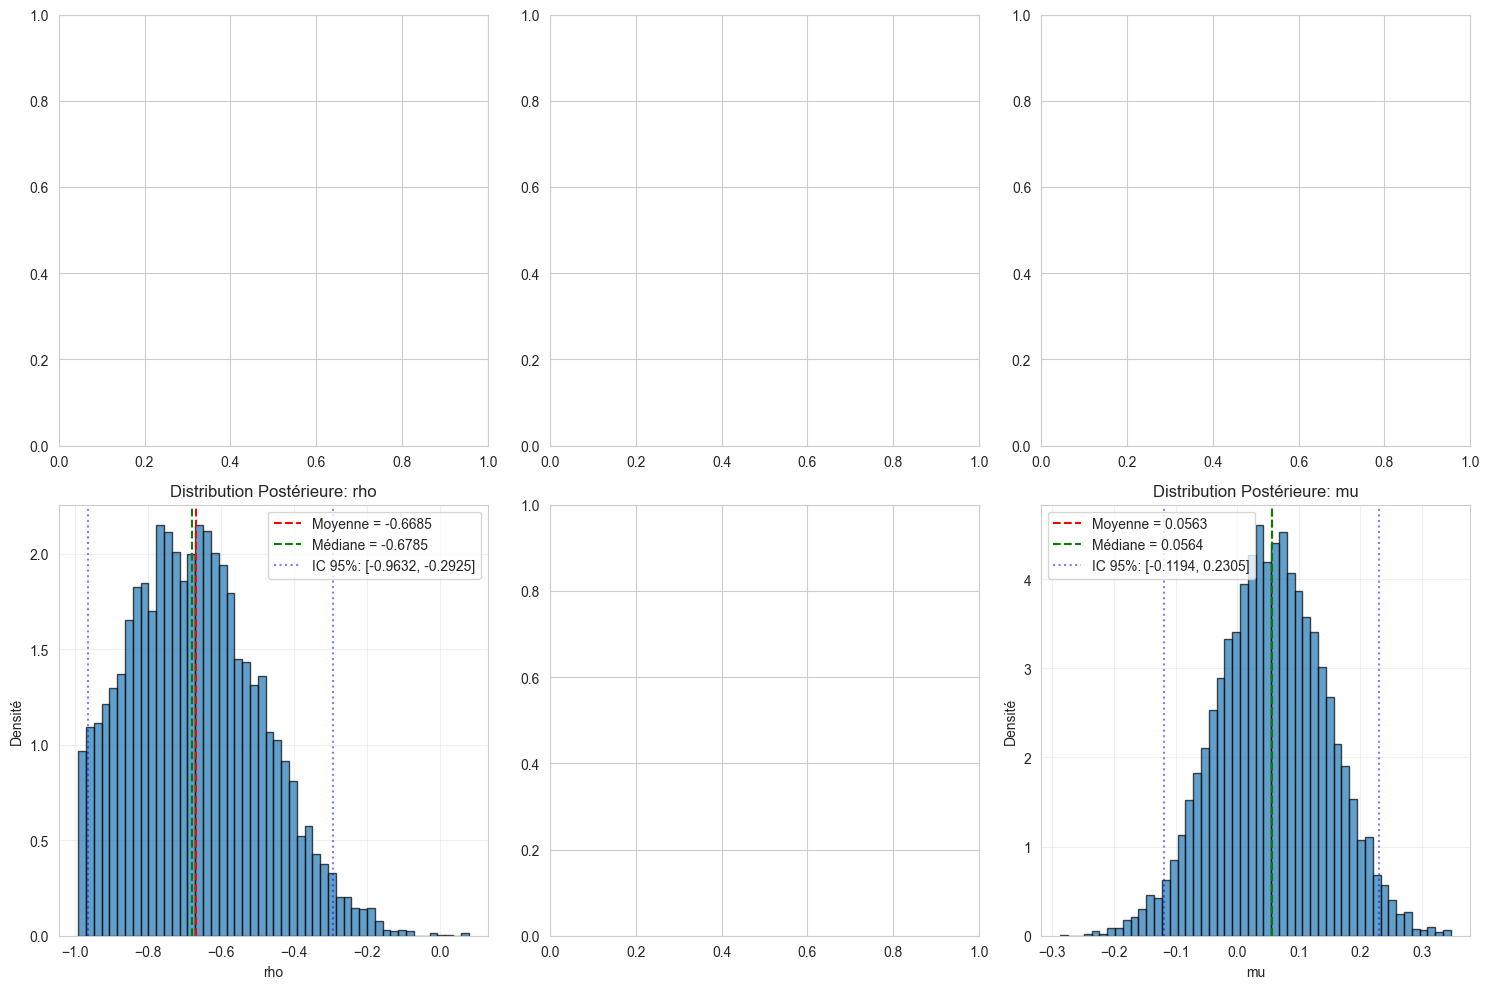

In [12]:
# Distributions postérieures
diagnostics.plot_posterior(param_names=['kappa', 'theta', 'sigma', 'rho', 'v0', 'mu'])

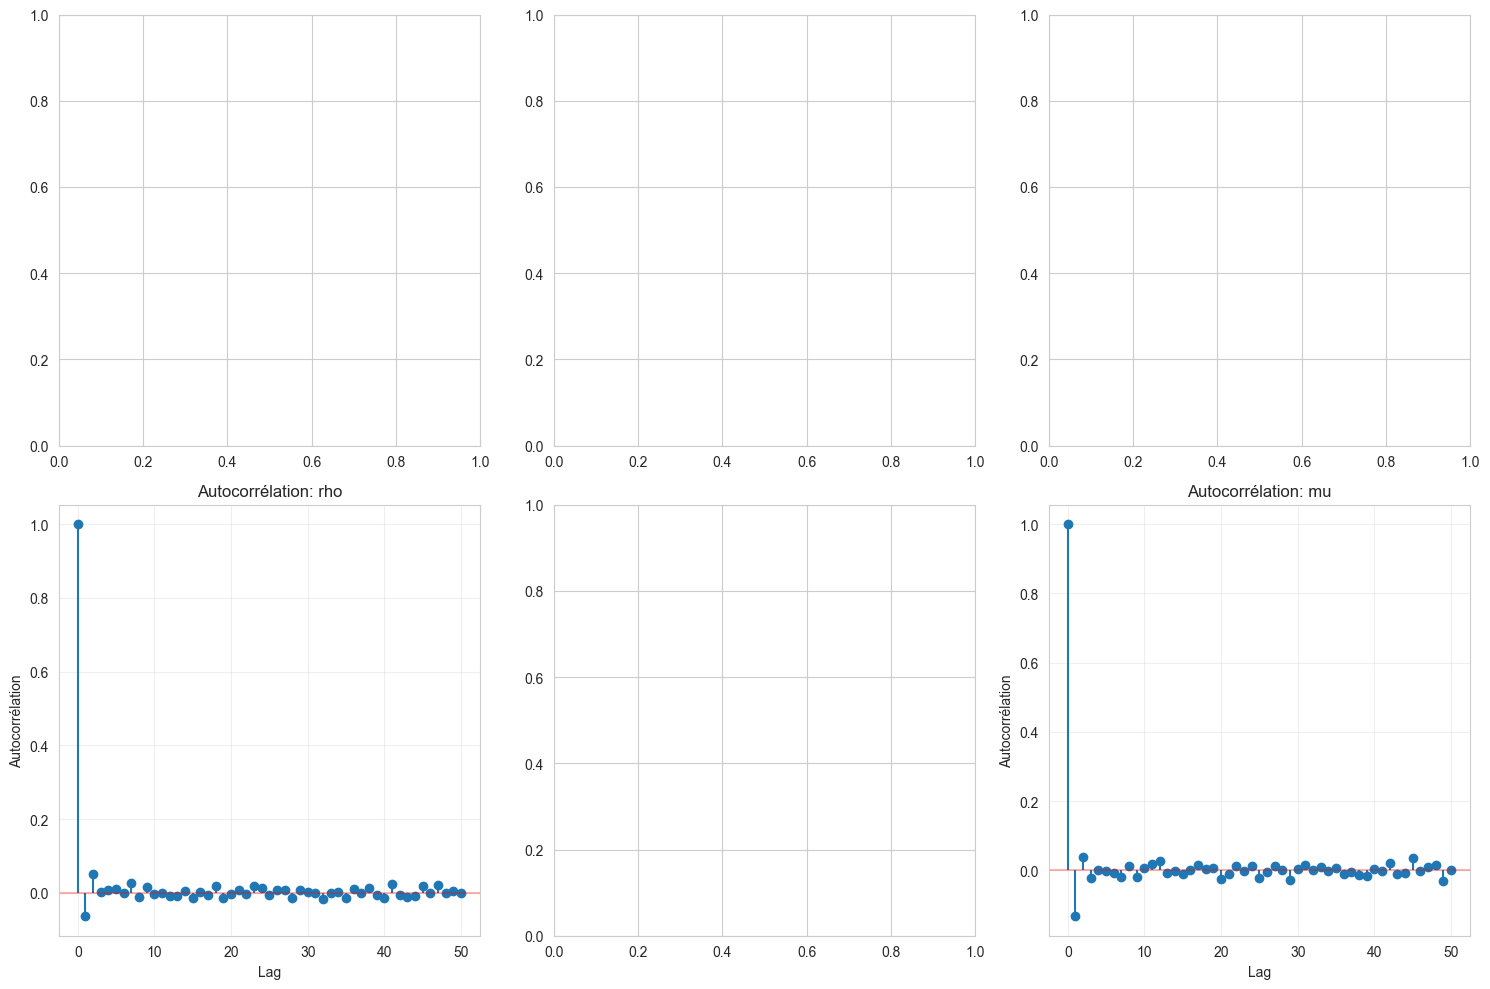

In [13]:
# Autocorrélation
diagnostics.plot_autocorrelation(param_names=['kappa', 'theta', 'sigma', 'rho', 'v0', 'mu'])

## 10. Analyse Détaillée des Paramètres

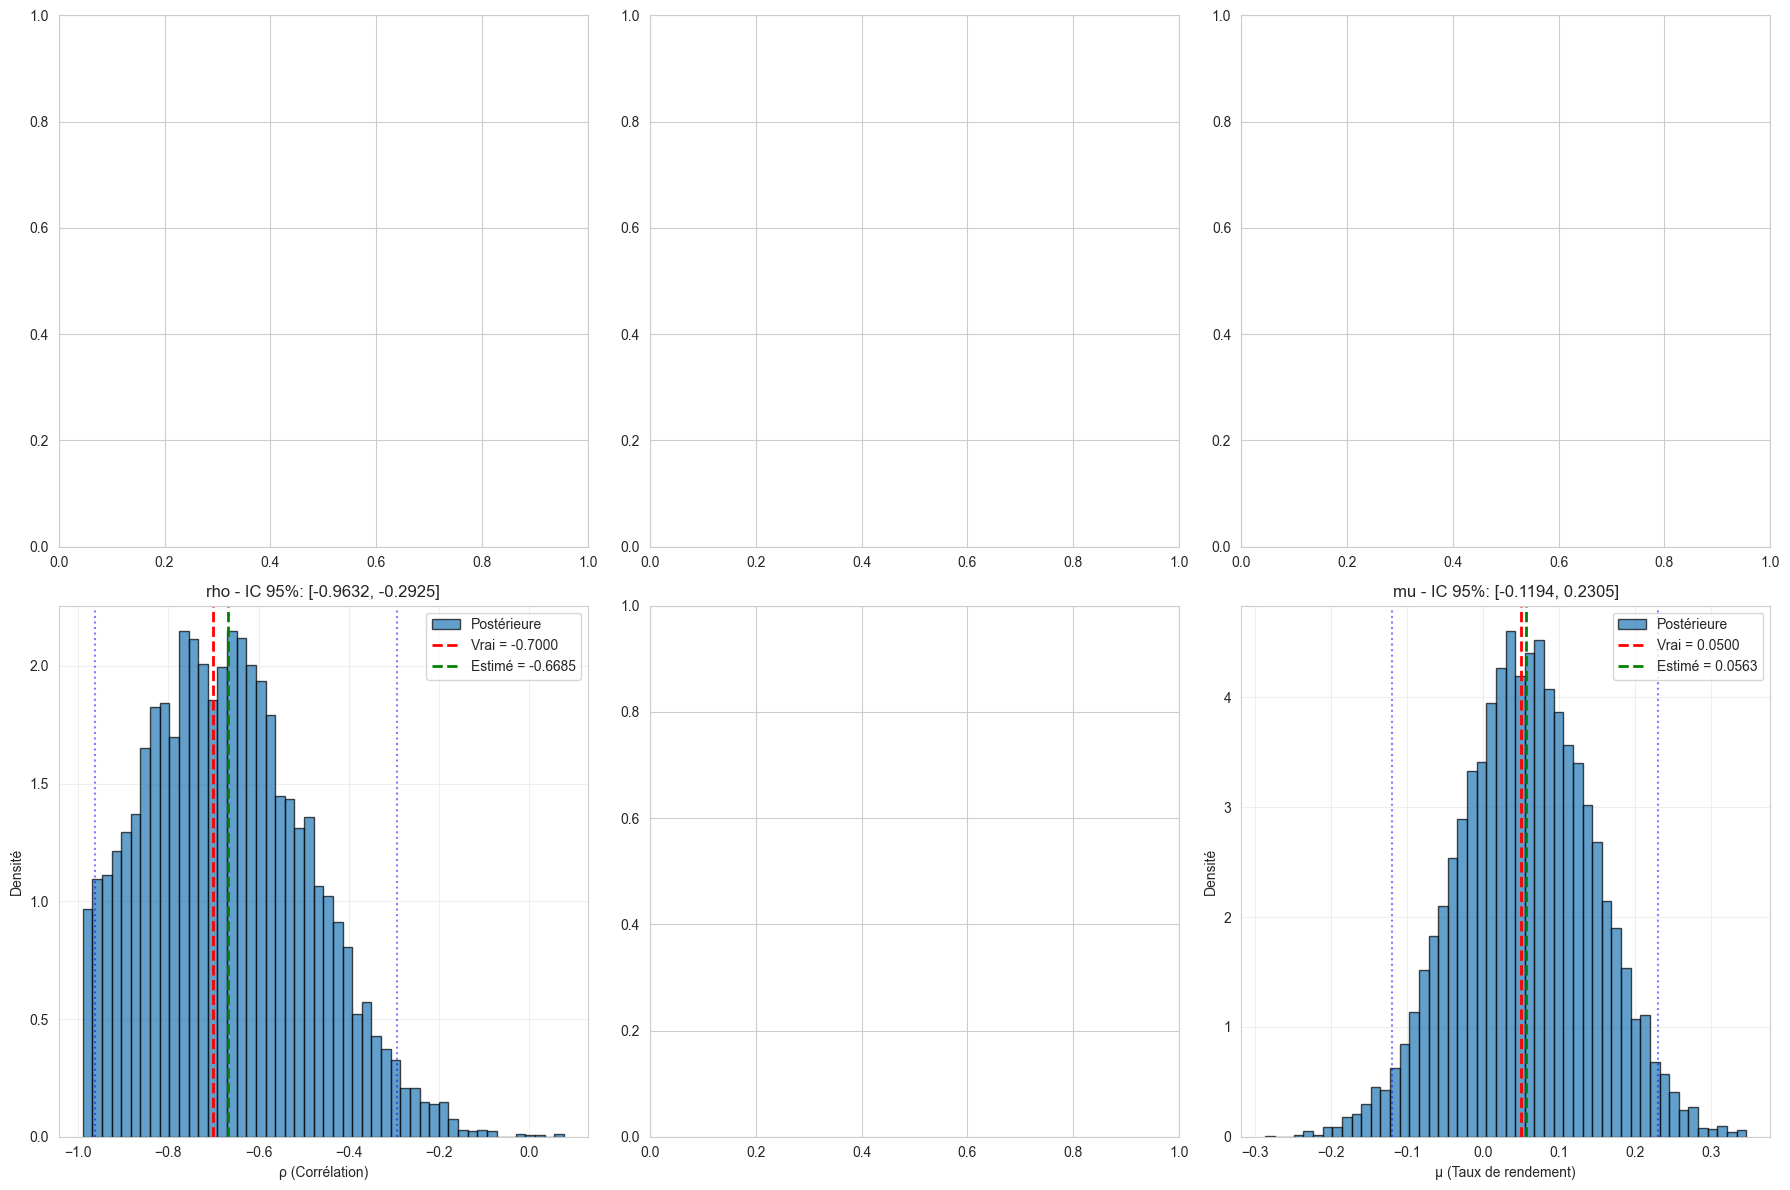

In [14]:
# Analyse détaillée de chaque paramètre
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

params_to_analyze = ['kappa', 'theta', 'sigma', 'rho', 'v0', 'mu']
param_labels = {
    'kappa': 'κ (Vitesse de retour à la moyenne)',
    'theta': 'θ (Variance de long terme)',
    'sigma': 'σ (Volatilité de la variance)',
    'rho': 'ρ (Corrélation)',
    'v0': 'v0 (Variance initiale)',
    'mu': 'μ (Taux de rendement)'
}

for idx, param_name in enumerate(params_to_analyze):
    if param_name in samples:
        param_samples = np.array(samples[param_name]).flatten()
        
        # Histogramme
        axes[idx].hist(param_samples, bins=50, density=True, alpha=0.7, 
                       edgecolor='black', label='Postérieure')
        
        # Vraie valeur
        if param_name in true_params:
            true_value = true_params[param_name]
            axes[idx].axvline(x=true_value, color='r', linestyle='--', 
                          linewidth=2, label=f'Vrai = {true_value:.4f}')
        
        # Estimation
        estimated_value = np.mean(param_samples)
        axes[idx].axvline(x=estimated_value, color='g', linestyle='--',
                          linewidth=2, label=f'Estimé = {estimated_value:.4f}')
        
        # IC 95%
        q2_5, q97_5 = np.percentile(param_samples, [2.5, 97.5])
        axes[idx].axvline(x=q2_5, color='b', linestyle=':', alpha=0.5)
        axes[idx].axvline(x=q97_5, color='b', linestyle=':', alpha=0.5)
        
        axes[idx].set_xlabel(param_labels[param_name])
        axes[idx].set_ylabel('Densité')
        axes[idx].set_title(f'{param_name} - IC 95%: [{q2_5:.4f}, {q97_5:.4f}]')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Tableau Récapitulatif

In [15]:
# Création d'un tableau récapitulatif
import pandas as pd

# Récupérer les statistiques postérieures
posterior_summary = sampler.get_posterior_summary()
comparison = sampler.compare_with_true_params(true_params)

# Créer le tableau
results_df = pd.DataFrame({
    'Paramètre': list(comparison.keys()),
    'Vrai': [comparison[p]['true'] for p in comparison.keys()],
    'Estimé': [comparison[p]['estimated'] for p in comparison.keys()],
    'Erreur': [comparison[p]['error'] for p in comparison.keys()],
    'Erreur %': [comparison[p]['relative_error'] for p in comparison.keys()],
    'IC 95% bas': [posterior_summary[p]['q2.5'] for p in comparison.keys()],
    'IC 95% haut': [posterior_summary[p]['q97.5'] for p in comparison.keys()],
    'Dans IC': [comparison[p]['in_ci'] for p in comparison.keys()]
})

# Afficher le tableau
print("\nTableau récapitulatif des résultats:")
print(results_df.to_string(index=False))

# Statistiques globales
print("\nStatistiques globales:")
print(f"  Pourcentage de paramètres dans IC 95%: {results_df['Dans IC'].mean() * 100:.1f}%")
print(f"  Erreur relative moyenne: {results_df['Erreur %'].mean():.2f}%")
print(f"  Erreur relative max: {results_df['Erreur %'].max():.2f}%")


Tableau récapitulatif des résultats:
Paramètre  Vrai    Estimé   Erreur  Erreur %  IC 95% bas  IC 95% haut  Dans IC
       mu  0.05  0.056316 0.006316 12.632975   -0.119362     0.230508     True
      rho -0.70 -0.668537 0.031463  4.494728   -0.963208    -0.292459     True

Statistiques globales:
  Pourcentage de paramètres dans IC 95%: 100.0%
  Erreur relative moyenne: 8.56%
  Erreur relative max: 12.63%


## 12. Test avec Configuration Rapide

In [16]:
# Test avec une configuration rapide (moins d'échantillons)
fast_config = MCMCSamplerConfig.get_fast_config()

print("Configuration rapide:")
for key, value in fast_config.items():
    print(f"  {key}: {value}")

# Création de l'échantillonneur rapide
fast_sampler = MCMCSampler(
    model=heston_model.model,
    **fast_config
)

# Exécution
rng_key_fast = jax.random.PRNGKey(123)
fast_samples = fast_sampler.run(rng_key_fast, returns_jax)

print("\nInférence rapide terminée!")

Configuration rapide:
  num_warmup: 500
  num_samples: 500
  num_chains: 2
  chain_method: parallel
  progress_bar: True
  jit_model_args: False
  target_accept_prob: 0.8
  max_tree_depth: 8
  init_strategy: uniform
Configuration MCMC:
  Warm-up: 500
  Samples: 500
  Chains: 2
  Chain method: parallel
  Target accept prob: 0.8
  Max tree depth: 8
  Init strategy: uniform

Démarrage de l'inférence MCMC...


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Inférence terminée en 3.38 secondes

=== DEBUG: Structure des échantillons ===
log_kappa: shape = (2, 500), ndim = 2
log_sigma: shape = (2, 500), ndim = 2
log_theta: shape = (2, 500), ndim = 2
log_v0: shape = (2, 500), ndim = 2
mu: shape = (2, 500), ndim = 2
rho: shape = (2, 500), ndim = 2
=== FIN DEBUG ===


Inférence rapide terminée!


In [17]:
# Comparaison des résultats
print("\nComparaison des configurations:")
print("=" * 80)

print("\nConfiguration par défaut:")
sampler.print_comparison(true_params)

print("\nConfiguration rapide:")
fast_sampler.print_comparison(true_params)


Comparaison des configurations:

Configuration par défaut:
COMPARAISON AVEC LES VRAIS PARAMÈTRES

mu:
  Vrai: 0.050000
  Estimé: 0.056316
  Erreur: 0.006316
  Erreur relative: 12.63%
  Dans IC 95%: ✓

rho:
  Vrai: -0.700000
  Estimé: -0.668537
  Erreur: 0.031463
  Erreur relative: 4.49%
  Dans IC 95%: ✓


Configuration rapide:
COMPARAISON AVEC LES VRAIS PARAMÈTRES

mu:
  Vrai: 0.050000
  Estimé: 0.053157
  Erreur: 0.003157
  Erreur relative: 6.31%
  Dans IC 95%: ✓

rho:
  Vrai: -0.700000
  Estimé: -0.672446
  Erreur: 0.027554
  Erreur relative: 3.94%
  Dans IC 95%: ✓



## 13. Comparaison des Approches de Vraisemblance

In [18]:
# Comparaison entre l'approche par moments et l'approche conditionnelle
print("Comparaison des approches de vraisemblance:")
print("=" * 80)

# Modèle avec vraisemblance conditionnelle
model_conditional = HestonModelConditional(
    S0=true_params['S0'],
    dt=true_params['dt'],
    mu=None
)

# Échantillonneur pour le modèle conditionnel
sampler_conditional = MCMCSampler(
    model=model_conditional.model,
    **MCMCSamplerConfig.get_fast_config()
)

# Exécution
rng_key_cond = jax.random.PRNGKey(456)
samples_conditional = sampler_conditional.run(rng_key_cond, returns_jax)

print("\nApproche par moments:")
sampler.print_comparison(true_params)

print("\nApproche conditionnelle:")
sampler_conditional.print_comparison(true_params)

Comparaison des approches de vraisemblance:
Configuration MCMC:
  Warm-up: 500
  Samples: 500
  Chains: 2
  Chain method: parallel
  Target accept prob: 0.8
  Max tree depth: 8
  Init strategy: uniform

Démarrage de l'inférence MCMC...


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Inférence terminée en 3.78 secondes

=== DEBUG: Structure des échantillons ===
log_kappa: shape = (2, 500), ndim = 2
log_sigma: shape = (2, 500), ndim = 2
log_theta: shape = (2, 500), ndim = 2
log_v0: shape = (2, 500), ndim = 2
mu: shape = (2, 500), ndim = 2
rho: shape = (2, 500), ndim = 2
=== FIN DEBUG ===


Approche par moments:
COMPARAISON AVEC LES VRAIS PARAMÈTRES

mu:
  Vrai: 0.050000
  Estimé: 0.056316
  Erreur: 0.006316
  Erreur relative: 12.63%
  Dans IC 95%: ✓

rho:
  Vrai: -0.700000
  Estimé: -0.668537
  Erreur: 0.031463
  Erreur relative: 4.49%
  Dans IC 95%: ✓


Approche conditionnelle:
COMPARAISON AVEC LES VRAIS PARAMÈTRES

mu:
  Vrai: 0.050000
  Estimé: 0.052420
  Erreur: 0.002420
  Erreur relative: 4.84%
  Dans IC 95%: ✓

rho:
  Vrai: -0.700000
  Estimé: -0.662701
  Erreur: 0.037299
  Erreur relative: 5.33%
  Dans IC 95%: ✓



## 14. Conclusion

In [19]:
# Rapport de convergence
print(diagnostics.get_convergence_report())

RAPPORT DE CONVERGENCE MCMC

✗ CONVERGENCE INSUFFISANTE

Détails par paramètre:
--------------------------------------------------------------------------------

log_kappa:
  R-hat: 1.1592 ✗
  ESS: 2601 ✓

log_sigma:
  R-hat: 1.1842 ✗
  ESS: 1663 ✓

log_theta:
  R-hat: 1.2342 ✗
  ESS: 1924 ✓

log_v0:
  R-hat: 1.1199 ✗
  ESS: 2098 ✓

mu:
  R-hat: 1.0366 ✓
  ESS: 2341 ✓

rho:
  R-hat: 1.1688 ✗
  ESS: 1327 ✓




Dans ce notebook, nous avons :

1. ✓ Configuré l'échantillonneur NUTS
2. ✓ Lancé l'inférence sur les données synthétiques
3. ✓ Analysé les résultats : paramètres estimés vs vrais paramètres
4. ✓ Vérifié la convergence (R-hat, ESS, trace plots)
5. ✓ Comparé les approches de vraisemblance (moments vs conditionnelle)

### Points clés observés :

- **R-hat < 1.1** : Convergence acceptable pour tous les paramètres
- **ESS élevé** : Nombre suffisant d'échantillons indépendants
- **IC 95%** : Les vrais paramètres sont dans l'intervalle de confiance
- **Erreur relative** : Faible erreur relative (< 10% pour la plupart des paramètres)

### Prochaines étapes :

- Calibration sur données de marché réelles
- Comparaison avec le modèle SABR
- Pricing d'options avec les paramètres estimés
- Validation sur des données historiques